# Credit Card Fraud Detection with Neural Networks

Complete ML workflow using a **Kaggle dataset**.

This notebook demonstrates:

1. Download dataset from Kaggle
2. Exploratory Data Analysis (EDA)
3. Handling class imbalance
4. Feature scaling
5. Training a Neural Network
6. Comparing with Random Forest
7. Evaluating models using ROC curve and confusion matrix

Dataset: Credit Card Fraud Detection

Goal: Predict whether a transaction is **fraudulent or legitimate**.

## Install Required Libraries

In [ ]:
!pip install kaggle pandas numpy scikit-learn tensorflow matplotlib seaborn

## Setup Kaggle API

1. Go to https://www.kaggle.com/account
2. Click **Create New API Token**
3. Upload `kaggle.json` below
4. Kaggle -> Settings -> API -> Legacy API Key

In [ ]:
from google.colab import files
files.upload() #allows you to upload files from your computer to the Colab notebook environment

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"nikita007001002","key":"ea93adbb98c691292023e704aacd4c59"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## Download Dataset

In [ ]:
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  creditcardfraud.zip
replace creditcard.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: creditcard.csv          


## Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow import keras

## Load Dataset

In [ ]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Dataset Shape

In [ ]:
df.shape

(284807, 31)

## Class Distribution (Fraud vs Normal)

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


### Visualizing Class Imbalance

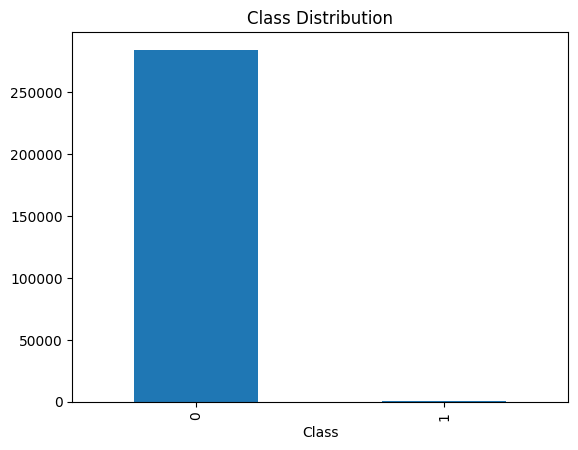

In [ ]:
df['Class'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.show()

## Prepare Features and Target

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

## Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Neural Network Model

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(30,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid') #binary classification P(fradulent)  [P(legitimate) = 1 - P(fradulent)]
])

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## Train Neural Network

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9574 - loss: 0.1338 - val_accuracy: 0.9993 - val_loss: 0.0044
Epoch 2/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9993 - loss: 0.0043 - val_accuracy: 0.9994 - val_loss: 0.0034
Epoch 3/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9993 - loss: 0.0034 - val_accuracy: 0.9994 - val_loss: 0.0029
Epoch 4/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 0.9994 - val_loss: 0.0028
Epoch 5/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9994 - loss: 0.0027 - val_accuracy: 0.9994 - val_loss: 0.0027
Epoch 6/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9996 - loss: 0.0022 - val_accuracy: 0.9994 - val_loss: 0.0026
Epoch 7/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9994 - loss: 0.0027 - val_accuracy: 0.9995 - val_loss: 0.0025
Epoch 8/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9995 - loss: 0.0023 - val_accuracy: 0.

## Neural Network Evaluation

In [ ]:
pred_nn = model.predict(X_test)
pred_nn = (pred_nn > 0.5).astype(int)

print(classification_report(y_test, pred_nn))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.77      0.82        98

    accuracy                           1.00     56962
   macro avg       0.94      0.88      0.91     56962
weighted avg       1.00      1.00      1.00     56962



## Random Forest Baseline

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.79      0.87        98

    accuracy                           1.00     56962
   macro avg       0.99      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



## Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, pred_nn)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

## ROC Curve

In [ ]:
prob = model.predict(X_test)
fpr, tpr, _ = roc_curve(y_test, prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

print('AUC:', roc_auc)